# Cars 4 You: Expediting Car Evaluations with ML

## 1. Data Import & Exploratory Data Analysis



#### **1.1. Importing the Libraries and Dataset**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
train= pd.read_csv("train.csv").copy() #importing the dataset
test=pd.read_csv("test.csv").copy()


#### **1.2. Initial Analysis**

In [3]:
#numero de linhas e colunas
print(train.shape) 

(75973, 14)


In [4]:
display(train.head())

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0


In [5]:
display(train.info()) # to see the data types and non-null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB


None

In [6]:
#definir as colunas como categoricas, numericas etc 
categorical_columns = train.select_dtypes(include=['object']).columns
numerical_columns = train.select_dtypes(include=['int64', 'float64']).columns
categorical_columns, numerical_columns

#futuramente fará sentido alterar o tipo de algumas colunas, como por exemplo year 

(Index(['Brand', 'model', 'transmission', 'fuelType'], dtype='object'),
 Index(['carID', 'year', 'price', 'mileage', 'tax', 'mpg', 'engineSize',
        'paintQuality%', 'previousOwners', 'hasDamage'],
       dtype='object'))

In [7]:
# Ao imprimir o inicio da tabela ja conseguimos perceber que temos missing values nomeadamente na coluna tax, e que temos inconsistências nas valores da variavel transmission por exemplo.
# No que toca a tipos de dados, as colunas year e previousOwners aparecem como float64 por causa dos missing values. Após imputação, serão convertidas para inteiros, uma vez que não fazem sentido como valores decimais. hasDamage será convertida para binária (0/1) para facilitar o encoding.
#falar do tipo de cada variavel, se é continua, categórica, ordinal, binária (?)

### 1.3. Categorical Variables Global Analysis

In [8]:
#vamos imprimir os valores únicos de cada coluna categórica para percebermos se existem inconsistências
for col in categorical_columns:
    unique_values = train[col].unique()
    print(f"Column: {col}, Unique Values: {unique_values}")

Column: Brand, Unique Values: ['VW' 'Toyota' 'Audi' 'Ford' 'BMW' 'Skoda' 'Opel' 'Mercedes' 'FOR'
 'mercedes' 'Hyundai' 'w' 'ord' 'MW' 'bmw' nan 'yundai' 'BM' 'Toyot' 'udi'
 'Ope' 'AUDI' 'V' 'opel' 'pel' 'For' 'pe' 'Mercede' 'audi' 'MERCEDES'
 'OPEL' 'koda' 'FORD' 'Hyunda' 'W' 'Aud' 'vw' 'hyundai' 'skoda' 'ford'
 'TOYOTA' 'ercedes' 'oyota' 'toyota' 'SKODA' 'Skod' 'HYUNDAI' 'kod' 'v'
 'for' 'SKOD' 'aud' 'KODA' 'PEL' 'yunda' 'or' 'UDI' 'OYOTA' 'HYUNDA' 'mw'
 'OPE' 'mercede' 'ERCEDES' 'ercede' 'TOYOT' 'MERCEDE' 'ORD' 'ud' 'ope'
 'AUD' 'hyunda' 'skod' 'toyot']
Column: model, Unique Values: [' Golf' ' Yaris' ' Q2' ' FIESTA' ' 2 Series' '3 Series' ' A3' ' Octavia'
 ' Passat' ' Focus' ' Insignia' ' A Clas' ' Q3' ' Fabia' ' A Class' ' Ka+'
 ' 3 Series' ' GLC Class' ' I30' ' C Class' ' Polo' ' E Class' ' C Clas'
 ' Q5' ' Up' ' Fiesta' ' C-HR' ' Mokka X' ' Corsa' ' Astra' ' TT'
 ' 5 Series' ' Aygo' ' 4 Series' ' SLK' ' Viva' ' T-Roc' 'Focus'
 ' EcoSport' ' Tucson' ' EcoSpor' nan ' X-CLASS' ' CL C

FALTAM COISAS NESTA SECÇÂO - alguns gráficos têm de estar aqui antes de haver qualquer tratamento (depois de tratados podem repetir-se)

### **1.4. Numerical Variables analysis**


In this section, we will analyse, generally, the values and study to know what will be needed in processing and cleaning 

We have the following numerical features in the dataset:
year,
price,
mileage,
tax,
mpg,
engineSize,
paintQuality%,
previousOwners,
hasDamage (althoug representing a binary feature)

-> Year: In this sub-section, we can see the global statistical data of this feature, as well as the distribution by year and percentages

In [98]:
#year column analysis
train['year'].describe()

count    74482.000000
mean      2017.096611
std          2.208704
min       1970.000000
25%       2016.000000
50%       2017.000000
75%       2019.000000
max       2024.121759
Name: year, dtype: float64

In [99]:
#year column analysis
train['year'].value_counts(normalize=True, dropna=False) * 100

year
2019.000000    26.681847
2017.000000    21.252287
2016.000000    15.139589
2018.000000    13.562713
2015.000000     7.546102
2020.000000     4.177800
2014.000000     3.856633
2013.000000     2.503521
NaN             1.962539
2012.000000     0.629171
2011.000000     0.418570
2010.000000     0.317218
2009.000000     0.300107
2008.000000     0.207969
2007.000000     0.161900
2010.676968     0.107933
2023.116964     0.101352
2005.000000     0.084240
2006.000000     0.081608
2010.746403     0.076343
2023.977311     0.072394
2023.389822     0.069762
2011.210853     0.065813
2010.565009     0.061864
2023.267989     0.056599
2023.605276     0.051334
2009.816757     0.048702
2010.371546     0.046069
2004.000000     0.046069
2024.121759     0.044753
2003.000000     0.038171
2023.367078     0.034223
2002.000000     0.032906
2012.695740     0.027641
2010.268635     0.026325
2022.696685     0.025009
2001.000000     0.019744
2011.111188     0.019744
2022.878006     0.015795
2000.000000     0.00

In [ ]:
train[train['year'] % 1 ==0]['year'].describe() # statistics with only integer values

count    73759.000000
mean      2017.097249
std          2.127952
min       1970.000000
25%       2016.000000
50%       2017.000000
75%       2019.000000
max       2020.000000
Name: year, dtype: float64

add graphic and distribution by 5 years 

hasDamage

In [ ]:
# check if hasdamage is either 1 or 0
print(train['hasDamage'].value_counts(dropna=False))

hasDamage
0.0    74425
NaN     1548
Name: count, dtype: int64


Previous owners

In [ ]:
#check if previous owners is an integer
print(train['previousOwners'].value_counts(dropna=False))
train['previousOwners'].describe() #media de todos 


previousOwners
 0.000000    14879
 4.000000    14763
 1.000000    14754
 3.000000    14649
 2.000000    14644
 NaN          1550
-2.340306       84
 6.258231       78
 6.245835       64
-2.345650       58
-2.339360       58
 6.258371       50
 6.233082       46
-2.299439       43
 6.230180       37
-2.335123       37
-2.312260       34
 6.248251       32
-2.337445       25
 6.217724       21
 6.241779       20
-2.340102       17
 6.227898       15
-2.317331       15
Name: count, dtype: int64


count    74423.000000
mean         1.994580
std          1.472981
min         -2.345650
25%          1.000000
50%          2.000000
75%          3.000000
max          6.258371
Name: previousOwners, dtype: float64

In [ ]:
train[(train['previousOwners'] >= 0) & (train['previousOwners'] % 1 == 0)]['previousOwners'].describe() #media de valores que sao inteiros e positivos


count    73689.000000
mean         1.995427
std          1.417058
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          4.000000
Name: previousOwners, dtype: float64

In [ ]:
#analyse paintquality 
train['paintQuality%'].value_counts(dropna=False)

paintQuality%
NaN           1524
34.000000     1147
94.000000     1128
54.000000     1114
32.000000     1107
              ... 
125.453599      23
2.725153        21
1.638913        19
125.188729      17
3.254760        15
Name: count, Length: 89, dtype: int64

In [ ]:
# checking how many negative values are in the paintquality column
print(train[train['paintQuality%'] < 0]['paintQuality%'].count())

0


In [ ]:
# how many values > 100 in paintquality
train[train['paintQuality%'] > 100]

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,tax_missing,mpg_missing
171,15717,FORD,FIESTA,2018.0,10491,MANUAL,6522.0,PETROL,145.0,65.7,1.0,125.109951,3.0,0.0,False,False
194,11200,BMW,4 SERIES,2019.0,23591,SEMI-AUTO,6100.0,PETROL,145.0,45.6,2.0,125.569499,2.0,0.0,False,False
272,53403,TOYOTA,AYGO,2016.0,7995,MANUAL,25300.0,NaN,0.0,69.0,1.0,125.594308,1.0,0.0,False,False
467,48038,SKODA,YETI OUTDOOR,2015.0,11995,SEMI-AUTO,19805.0,PETROL,125.0,51.4,1.2,125.453599,1.0,0.0,False,False
583,10137,BMW,5 SERIES,2017.0,21995,AUTOMATIC,18820.0,DIESEL,145.0,65.7,2.0,125.569499,4.0,0.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74763,75768,VW,TIGUAN ALLSPACE,2018.0,18499,MANUAL,24940.0,PETROL,145.0,48.7,1.4,125.366507,0.0,0.0,False,False
75073,39666,MERCEDES,GLE CLASS,2017.0,21602,SEMI-AUTO,40690.0,DIESEL,145.0,NaN,3.0,125.202033,3.0,0.0,False,True
75135,23930,FORD,FIESTA,2020.0,15000,MANUAL,35.0,PETROL,145.0,56.5,1.0,125.109951,0.0,0.0,False,False
75540,38756,MERCEDES,GLS CLASS,2016.0,36495,SEMI-AUTO,33000.0,DIESEL,300.0,37.2,3.0,125.202033,2.0,0.0,False,False


In [ ]:
#descriptive statistics for paintquality 
train['paintQuality%'].describe()

count    74449.000000
mean        64.590667
std         21.021065
min          1.638913
25%         47.000000
50%         65.000000
75%         82.000000
max        125.594308
Name: paintQuality%, dtype: float64

In [ ]:
train[(train['paintQuality%'] >= 0) & (train['paintQuality%'] <= 100)]['paintQuality%'].describe()



count    74082.000000
mean        64.290118
std         20.633703
min          1.638913
25%         47.000000
50%         64.000000
75%         82.000000
max         99.000000
Name: paintQuality%, dtype: float64

In [ ]:
# analyzing the engineSize column
train['engineSize'].value_counts(dropna=False)

engineSize
 2.000000    20105
 1.000000    13615
 1.500000     9156
 1.400000     7432
 1.600000     6381
 1.200000     4750
 3.000000     3806
 2.100000     3624
 NaN          1516
 1.800000     1192
 1.300000      920
 1.700000      618
 1.100000      385
 2.500000      312
 2.200000      295
 4.000000      295
 2.300000      181
 0.000000      180
 2.900000      116
-0.103493       84
 2.631200       80
 0.307074       65
 3.723712       63
 2.985793       52
 0.739534       52
 0.186425       52
 2.064119       51
 4.400000       46
 2.400000       43
 0.154529       39
 5.000000       38
 3.739235       38
 0.313407       35
 5.500000       31
 3.822758       27
 2.800000       26
 2.619641       25
 0.162866       24
 1.900000       23
 0.191462       21
 4.200000       20
 3.200000       19
 6.200000       19
 2.781776       19
 0.371127       18
 4.700000       18
 5.200000       17
 2.663113       17
 3.500000       12
 2.700000        7
 0.600000        4
 5.400000        2
 

In [101]:
# engine size descriptive statistics
train['engineSize'].describe()
train[train['engineSize'] > 0]['engineSize'].describe()
#assessing the mileage column  
train['mileage'].value_counts(dropna=False)
train['mileage'].describe()
train[train['mileage']>0]['mileage'].describe()
#tax collumn analysis
train['tax'].value_counts(dropna=False)
train['tax'].describe()
train[train['tax']>=0]['tax'].describe()
# mpg column analysis
train['mpg'].value_counts(dropna=False)
train['mpg'].describe()
train[train['mpg']>0]['mpg'].describe()
#price analysis
train['price'].value_counts(dropna=False)
train['price'].describe()


count     75973.000000
mean      16881.889553
std        9736.926322
min         450.000000
25%       10200.000000
50%       14699.000000
75%       20950.000000
max      159999.000000
Name: price, dtype: float64

1.5. Cross analysis

## 2. 

In [9]:
#conseguimos perceber que há inconsistencias em todas as colunas categóricas
#começamos por passar todas as colunas categoricas para upper case e retirar os espaços em branco do inicio e fim da string
for column in categorical_columns:
    train[column] = train[column].str.upper().str.strip()  
    print(f"Unique values in column '{column}' after stripping and uppercasing: {train[column].unique()}") 


Unique values in column 'Brand' after stripping and uppercasing: ['VW' 'TOYOTA' 'AUDI' 'FORD' 'BMW' 'SKODA' 'OPEL' 'MERCEDES' 'FOR'
 'HYUNDAI' 'W' 'ORD' 'MW' nan 'YUNDAI' 'BM' 'TOYOT' 'UDI' 'OPE' 'V' 'PEL'
 'PE' 'MERCEDE' 'KODA' 'HYUNDA' 'AUD' 'ERCEDES' 'OYOTA' 'SKOD' 'KOD'
 'YUNDA' 'OR' 'ERCEDE' 'UD']
Unique values in column 'model' after stripping and uppercasing: ['GOLF' 'YARIS' 'Q2' 'FIESTA' '2 SERIES' '3 SERIES' 'A3' 'OCTAVIA'
 'PASSAT' 'FOCUS' 'INSIGNIA' 'A CLAS' 'Q3' 'FABIA' 'A CLASS' 'KA+'
 'GLC CLASS' 'I30' 'C CLASS' 'POLO' 'E CLASS' 'C CLAS' 'Q5' 'UP' 'C-HR'
 'MOKKA X' 'CORSA' 'ASTRA' 'TT' '5 SERIES' 'AYGO' '4 SERIES' 'SLK' 'VIVA'
 'T-ROC' 'ECOSPORT' 'TUCSON' 'ECOSPOR' nan 'X-CLASS' 'CL CLASS' 'IX20'
 'I20' 'RAPID' 'A1' 'AURIS' 'SHARAN' 'ADAM' 'X3' 'A8' 'GLS CLASS' 'B-MAX'
 'A4' 'KONA' 'I10' 'MOKKA' 'S-MAX' 'X2' 'CROSSLAND X' 'TIGUAN' 'A5'
 'GLE CLASS' 'ZAFIRA' 'IONIQ' 'A6' 'MONDEO' 'YETI OUTDOOR' 'X1' 'SCALA'
 'S CLASS' '1 SERIES' 'KAMIQ' 'KUGA' 'TOURNEO CONNECT' 'Q7' 'GLA C

/var/folders/bd/t15rp69d53n0dgbv492qs36h0000gn/T/ipykernel_84417/996597199.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/bd/t15rp69d53n0dgbv492qs36h0000gn/T/ipykernel_84417/996597199.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/bd/t15rp69d53n0dgbv492qs36h0000gn/T/ipykernel_84417/996597199.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/bd/t15rp69d53n0dgbv492qs36h0000gn/T/ipykernel_84417/996597199.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

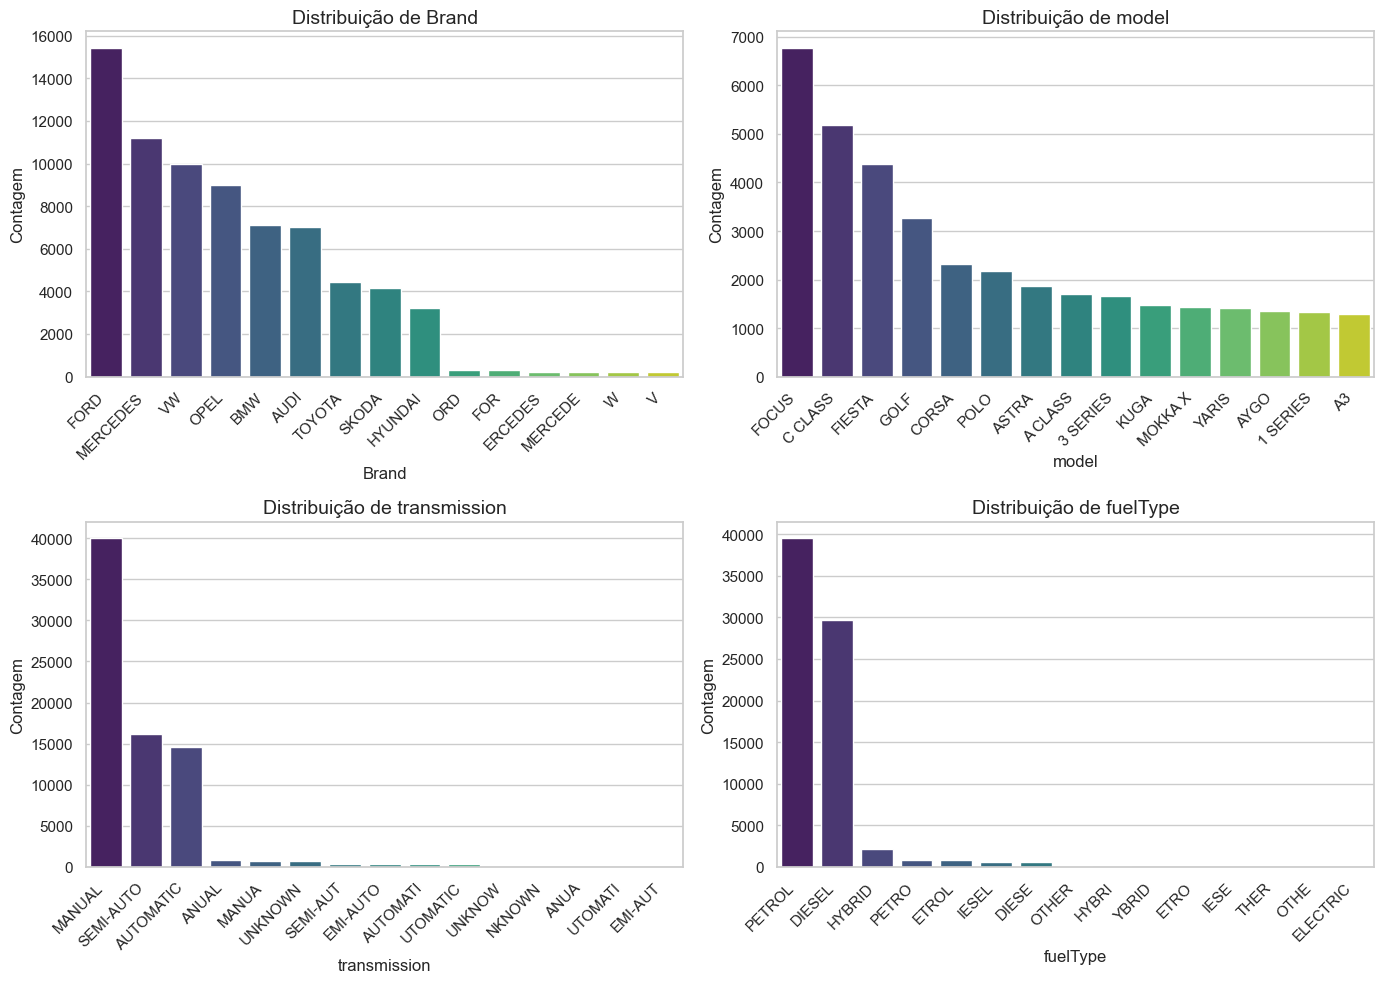

In [10]:
sns.set(style="whitegrid")

# Cria um subplot por variável
n_cols = 2
n_rows = (len(categorical_columns) + 1) // n_cols

plt.figure(figsize=(14, 5 * n_rows))

for i, col in enumerate(categorical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    
    # Mostra as 15 categorias mais comuns
    top_values = train[col].value_counts().head(15)
    
    sns.barplot(
        x=top_values.index,
        y=top_values.values,
        palette="viridis"
    )
    
    plt.title(f"Distribuição de {col}", fontsize=14)
    plt.ylabel("Contagem")
    plt.xlabel(col)
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [11]:
# o meu objetivo com estes graficos era perceber se existia a possibilidade de definir um threshold de frequencia para distinguir valores validos de invalidos
# so que nao funciona para os modelos claramente
# no entanto para as outras var alem do model acho que pode funcionar, so que por exemplo em fueltype tens o eletric que é valido so que como só tem uma amostra vai acabar por nao estar na lista dos validos, mas dá para resolver acho eu

In [12]:
train['model'].value_counts()

model
FOCUS             6775
C CLASS           5194
FIESTA            4384
GOLF              3261
CORSA             2319
                  ... 
TIGUAN ALLSPAC       1
8 SERIE              1
230                  1
FOX                  1
TERRACAN             1
Name: count, Length: 296, dtype: int64

In [13]:
#esta função eu acabei por perceber que não funciona porque por exemplo para o caso de UD que pode ser tanto audi como hyundai, e se eu substituir logo por audi ou hyundai (dependendo do que vai aparecer primeiro), depois quando chegar a hyundai ou audi ja nao vou conseguir perceber que é ambiguo

def normalize_by_containment(values):
    valores_unicos = [v for v in pd.Series(values).dropna().unique() if isinstance(v, str)]
    lista_limpa = []
    mapping = {}
    ambiguos = set()

    for v in valores_unicos:
        # procura valores já na lista que contenham ou sejam contidos por v
        candidatos = [x for x in lista_limpa if v in x or x in v]

        # se não há candidatos, adiciona
        if not candidatos:
            lista_limpa.append(v)
            mapping[v] = v
            continue

        # se há mais de um candidato, é ambíguo — não muda, mas regista
        if len(candidatos) > 1:
            mapping[v] = v
            ambiguos.add(v)
            continue

        # se há só um candidato
        c = candidatos[0]
        if v in c:
            # valor é substring do existente
            mapping[v] = c
        elif c in v:
            # valor é superstring — substitui o existente
            lista_limpa.remove(c)
            lista_limpa.append(v)
            # atualiza todos que apontavam para c
            for k in list(mapping.keys()):
                if mapping[k] == c:
                    mapping[k] = v
            mapping[v] = v
        else:
            mapping[v] = v  # fallback (não devia acontecer)

    valores_normalizados = [mapping.get(v, v) for v in values]
    return valores_normalizados, sorted(list(ambiguos))


ambiguous_summary = {}

for col in categorical_columns:
    print(f"\nNormalizando coluna: {col}")

    # aplica a função
    train[col], ambiguos = normalize_by_containment(train[col])

    # guarda os ambíguos encontrados (se houver)
    if ambiguos:
        ambiguous_summary[col] = ambiguos
        print(f" Valores ambíguos encontrados ({len(ambiguos)}): {ambiguos}")
    else:
        print(" Nenhum valor ambíguo encontrado.")




Normalizando coluna: Brand
 Valores ambíguos encontrados (1): ['W']

Normalizando coluna: model
 Valores ambíguos encontrados (18): ['A', 'ADA', 'CADDY', 'I', 'IQ', 'K', 'KA', 'M', 'Q', 'RAV', 'RS', 'S CLAS', 'SL', 'T', 'U', 'VERS', 'X', 'Z']

Normalizando coluna: transmission
 Nenhum valor ambíguo encontrado.

Normalizando coluna: fuelType
 Nenhum valor ambíguo encontrado.


In [14]:
#ignorem esta função sou eu a pensar, mas aqui esta vai ser a função que vou usar para normalizar os valores depois de ter a lista dos valores válidos 


# aqui vou ter de criar uma lista so com velores que nao tem interseção e a partir daí começo a fazer as comparações
# ha aqui tambem um problema que é "etro" tambem esta em petrol e other com a função do contain... 
# é preciso mudar isto de modo a que, quando estamos a analisar um valor tambem sejam tidos em conta os valores que vêm a seguir para analise, porque por exemplo, UD pode estar para representar AUDI mas tambem Hyundai, nao sabemos de que forma os dados foram alterador, e para estar a prova de bala, preciso que nao se susbtituam logo valores sabendo que pode vir um nome a seguir que o torne ambiguo, faz sentido?


#o que quero fazer é, criar ua lista de todas os valores unicos que nao estao contidos uns nos outros
# a partir daí, das palavras que sobraraam ver as que estão contidas em apenas 1 palavra da lista inicial 
# se estiverem contidas em mais do que uma palavra, são ambiguas e não se alteram
#se estiveram contidas numa so palavra entao passam a ser a palavra em que estao contidas
#depois para as palavras que deram ambiguas, vou criar uma função que recebe a lista de ambiguos e uma coluna de suporte, isto é, para cada valor ambiguo, vamos verificar na coluna de suporte se ha mais iguais por exemplo; temos uma marca ambigua, vamos ver se na coluna model ha mais models iguais, se houver, então alteramos a marca para a marca que está na coluna model
# os que nao nao houver outro model assim, 


def normalize_by_containment(values):
    valores_unicos = [v for v in pd.Series(values).dropna().unique() if isinstance(v, str)]
    lista_limpa = []
    mapping = {}
    ambiguos = set()

    for v in valores_unicos:
        # procura valores já na lista que contenham ou sejam contidos por v
        candidatos = [x for x in lista_limpa if v in x or x in v]

        # se não há candidatos, adiciona
        if not candidatos:
            lista_limpa.append(v)
            mapping[v] = v
            continue

        # se há mais de um candidato, é ambíguo — não muda, mas regista
        if len(candidatos) > 1:
            mapping[v] = v
            ambiguos.add(v)
            continue

        # se há só um candidato
        c = candidatos[0]
        if v in c:
            # valor é substring do existente
            mapping[v] = c
        elif c in v:
            # valor é superstring — substitui o existente
            lista_limpa.remove(c)
            lista_limpa.append(v)
            # atualiza todos que apontavam para c
            for k in list(mapping.keys()):
                if mapping[k] == c:
                    mapping[k] = v
            mapping[v] = v
        else:
            mapping[v] = v  # fallback (não devia acontecer)

    valores_normalizados = [mapping.get(v, v) for v in values]
    return valores_normalizados, sorted(list(ambiguos))


In [15]:
#normalizar os valores de cada coluna categórica
ambiguous_summary = {}

for col in categorical_columns:
    print(f"\n Coluna normalizada: {col}")

    train[col], ambiguos = normalize_by_containment(train[col])

    if ambiguos:
        ambiguous_summary[col] = ambiguos
        print(f" Valores ambíguos encontrados ({len(ambiguos)}): {ambiguos}")
    else:
        print(" Nenhum valor ambíguo encontrado.")
  


 Coluna normalizada: Brand
 Valores ambíguos encontrados (1): ['W']

 Coluna normalizada: model
 Valores ambíguos encontrados (18): ['A', 'ADA', 'CADDY', 'I', 'IQ', 'K', 'KA', 'M', 'Q', 'RAV', 'RS', 'S CLAS', 'SL', 'T', 'U', 'VERS', 'X', 'Z']

 Coluna normalizada: transmission
 Nenhum valor ambíguo encontrado.

 Coluna normalizada: fuelType
 Nenhum valor ambíguo encontrado.


#### **Missing Values**

In [16]:
#counting the number of duplicated rows
print(train.duplicated().sum()) #0 duplicated rows
#porque seria importante?

0


In [17]:
#contagem de missing values por coluna e qual a percentagem 
missing_values = train.isnull().sum()
missing_percentage = (train.isnull().sum() / len(train)) * 100
missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
print(missing_data)
#lots of missing values in all the colums except the carID and price

                Missing Values  Percentage
carID                        0    0.000000
Brand                     1521    2.002027
model                     1517    1.996762
year                      1491    1.962539
price                        0    0.000000
transmission              1522    2.003343
mileage                   1463    1.925684
fuelType                  1511    1.988864
tax                       7904   10.403696
mpg                       7926   10.432654
engineSize                1516    1.995446
paintQuality%             1524    2.005976
previousOwners            1550    2.040198
hasDamage                 1548    2.037566


In [18]:
# temos duas categorias principais de missing values, de 2% e de 10% de missing values 
# as com percentagem de missing values de 2% penso que nao consistem numa percentagem de missing values significativa 
# vamos analisar a distribuicao dos dados para perceber que abordagem faz mais sentido
# analisar garficos para perceber o que fazer com os missing values 


<Axes: >

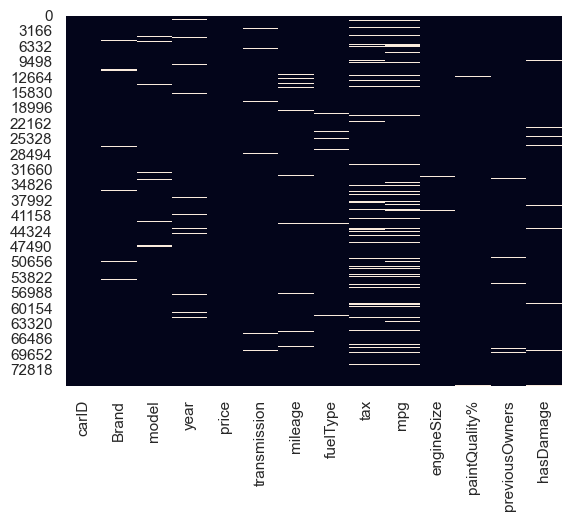

In [19]:
sns.heatmap(train.isna(), cbar=False)

In [20]:
# Com este gráfico podemos reparar que quase todos os missing values de tax e mpg que são as variaveis que têm % de missing values mais significativa, estão juntos, isto faz sentido uma vez que carros eletricos ou hibridos(aqui nao sei se se aplica), nao têm mpg e estao muitas vezes isentos de taxas

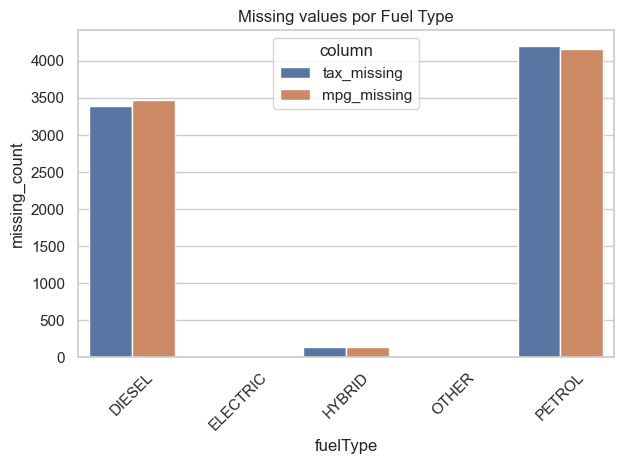

In [21]:
train['tax_missing'] = train['tax'].isna()
train['mpg_missing'] = train['mpg'].isna()

missing_counts = train.groupby('fuelType')[['tax_missing', 'mpg_missing']].sum().reset_index()
missing_melted = missing_counts.melt(id_vars='fuelType', var_name='column', value_name='missing_count')


sns.barplot(data=missing_melted, x='fuelType', y='missing_count', hue='column')
plt.title('Missing values por Fuel Type')
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()



In [22]:
# fiz este grafico para tentar provar o meu ponto anterior e o grafico provou me exatamente o contrario, giro

## Alguns graficos e estatisticas que podem fazer sentido (não acabei)

In [23]:
#calculate some basic statistics for numerical columns
display(train.describe())

,carID,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,75973.000000,74482.000000,75973.000000,74510.000000,68069.000000,68047.000000,74457.000000,74449.000000,74423.000000,74425.0
mean,37986.000000,2017.096611,16881.889553,23004.184088,120.329078,55.152666,1.660136,64.590667,1.994580,0.0
std,21931.660338,2.208704,9736.926322,22129.788366,65.521176,16.497837,0.573462,21.021065,1.472981,0.0
min,0.000000,1970.000000,450.000000,-58540.574478,-91.121630,-43.421768,-0.103493,1.638913,-2.345650,0.0
25%,18993.000000,2016.000000,10200.000000,7423.250000,125.000000,46.300000,1.200000,47.000000,1.000000,0.0
50%,37986.000000,2017.000000,14699.000000,17300.000000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,56979.000000,2019.000000,20950.000000,32427.500000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,75972.000000,2024.121759,159999.000000,323000.000000,580.000000,470.800000,6.600000,125.594308,6.258371,0.0


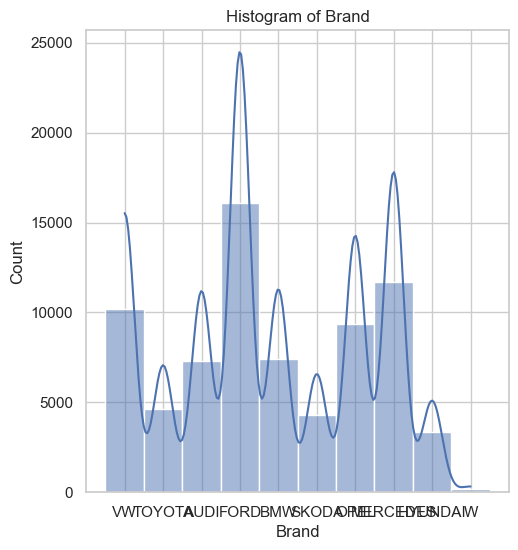

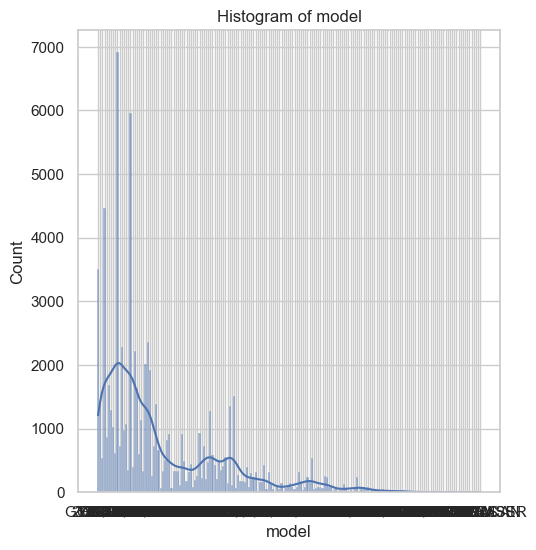

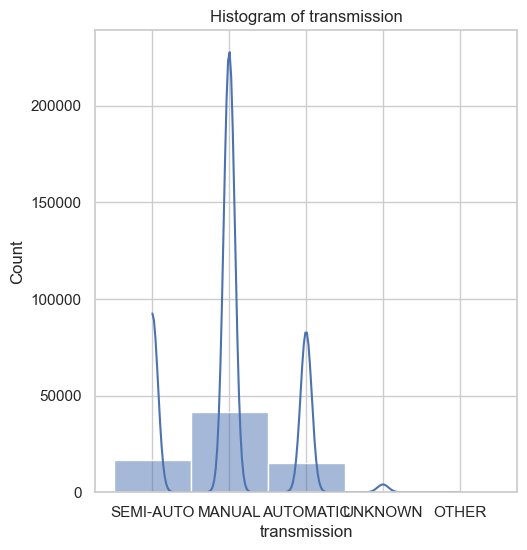

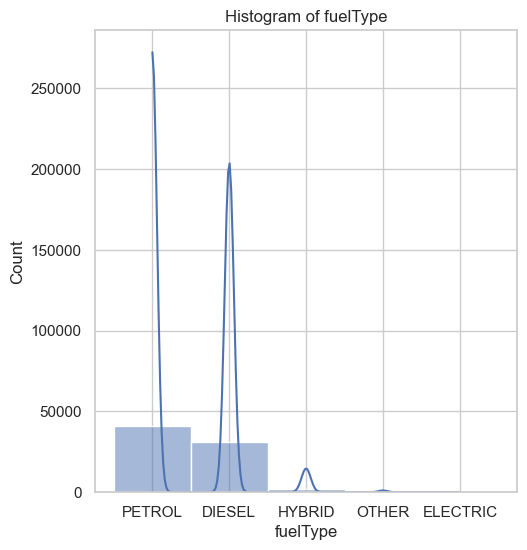

In [24]:
#Create graphics for numerical columns(histograms, boxplots, scatter plots)
numerical_columns = train.select_dtypes(include=[np.number]).columns.tolist()
for column in categorical_columns:
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    sns.histplot(train[column].dropna(), kde=True)
    plt.title(f'Histogram of {column}')
    
    plt.show()

#fazer mais graficos e tirar boas conclusoes dos gráficos 


## Analyzing the numerical data 

We have the following numerical features in the dataset:
year,
price,
mileage,
tax,
mpg,
engineSize,
paintQuality%,
previousOwners,
hasDamage (althoug representing a binary feature)

Each of them, has its own constraints, and this values should satisfy these conditions
\[
\begin{aligned}
\text{year} &\in [1900, 2020] \\[6pt]
\text{mileage} &\geq 0 \\[6pt]
\text{tax} &\geq 0 \\[6pt]
\text{mpg} &> 0 \\[6pt]
\text{engineSize} &> 0 \\[6pt]
\text{paintQuality\%} &\in [0, 100] \\[6pt]
\text{previousOwners} &\in \mathbb{N}_0 = \{0, 1, 2, \dots\} \\[6pt]
\text{hasDamage} &\in \{0, 1\}
\end{aligned}
\]

Analisando as médias e os restantes valores é possível constatar que não há grandes diferenças nos valores descritivos entre os previous owners n filtrados e aqueles cujos valores são somente inteiro positivos 
--> Decidir o que fazer aos Nan e aos valores negativos

The "year" column contains values between 1970 and approximately 2024. The presence of decimal values may result from typos or from calculating the fractional number of years (i.e. including the number of months). However, the exact number of months a car has is typically not very relevant for price estimation - the car's age in full years matters most. Additionally, users will probably not calculate (or at least not correctly) the exact fractional age of the car. 

-> Therefore, we round all "year" values down to the floor integer. 

Moreover, the entries that didn't contain a "year" value were removed from the dataset. This decision is based on the fact that a car's year is one of the most relevant factors in determining its price. Replacing these missing values with a constant or with a statistical estimate (such as the mean or median) could lead to unreliable results. Since they represent only about 2% of the dataset, removing them was considered the safest option to ensure reliable outcomes. 

In [88]:
train = train.dropna(subset=['year'])  #removing rows with missing year values
train['year'] = np.floor(train['year']) #rounding down to the nearest integer

test['year'] = np.floor(test['year'])


/var/folders/bd/t15rp69d53n0dgbv492qs36h0000gn/T/ipykernel_84417/2590431026.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['year'] = np.floor(train['year']) #rounding down to the nearest integer


In [90]:
train['year'].describe()

count    74482.000000
mean      2017.091821
std          2.211113
min       1970.000000
25%       2016.000000
50%       2017.000000
75%       2019.000000
max       2024.000000
Name: year, dtype: float64

In [91]:
train['year'].value_counts(normalize=True, dropna=False) * 100

year
2019.0    27.215972
2017.0    21.677721
2016.0    15.442657
2018.0    13.834215
2015.0     7.697162
2020.0     4.261432
2014.0     3.933836
2013.0     2.553637
2012.0     0.669961
2010.0     0.648479
2011.0     0.514218
2023.0     0.393384
2009.0     0.355791
2008.0     0.212132
2007.0     0.165141
2005.0     0.085927
2006.0     0.083242
2004.0     0.046991
2024.0     0.045649
2022.0     0.041621
2003.0     0.038936
2002.0     0.033565
2001.0     0.020139
2000.0     0.008056
1998.0     0.006713
1999.0     0.006713
1970.0     0.002685
1997.0     0.002685
1996.0     0.001343
Name: proportion, dtype: float64